Iris Dataset Decision Tree

In [1]:
print("Hello world")

Hello world


In [2]:
import pandas as pd

In [3]:
# Age is in a differen scale than estimated salary. Thus we need to convert them into a standard scale.

In [4]:
df = pd.read_csv("/home/msis/ahegde/aml-lab/projects/data/Iris.csv")

In [5]:
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,1
1,2,4.9,3.0,1.4,0.2,1
2,3,4.7,3.2,1.3,0.2,1
3,4,4.6,3.1,1.5,0.2,1
4,5,5.0,3.6,1.4,0.2,1
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,2
146,147,6.3,2.5,5.0,1.9,2
147,148,6.5,3.0,5.2,2.0,2
148,149,6.2,3.4,5.4,2.3,2


In [6]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,1
1,2,4.9,3.0,1.4,0.2,1
2,3,4.7,3.2,1.3,0.2,1
3,4,4.6,3.1,1.5,0.2,1
4,5,5.0,3.6,1.4,0.2,1


In [7]:
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
x = df.iloc[:,1:5].values
x

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [10]:
y = df.iloc[:, -1].values
y

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [11]:
import numpy as np

In [26]:
from sklearn.preprocessing import StandardScaler
sc_x = StandardScaler()
x_kt = sc_x.fit_transform(x)

In [28]:
from sklearn.model_selection import KFold, cross_val_score

In [33]:
from sklearn import tree
clf = tree.DecisionTreeClassifier(criterion='entropy', random_state=42)
#clf = tree.DecisionTreeClassifier(criterion='gini')

In [34]:
# Use kfold cross validation

k_n = [2, 3, 4, 5]

for kn in k_n:
    kf = KFold(n_splits=kn)
    scores = cross_val_score(clf, x_kt, y, cv=kf)
    print(f"K={kn}")
    print(f"Mean Accuracy: {np.mean(scores):.4f}")
    print(f"Std dev: {np.std(scores):.4f}")
    print(f"Fold Scores: {np.round(scores, 4)}")
    print(" ")


K=2
Mean Accuracy: 0.3267
Std dev: 0.0067
Fold Scores: [0.32   0.3333]
 
K=3
Mean Accuracy: 0.0000
Std dev: 0.0000
Fold Scores: [0. 0. 0.]
 
K=4
Mean Accuracy: 0.8855
Std dev: 0.1122
Fold Scores: [1.     0.9474 0.8919 0.7027]
 
K=5
Mean Accuracy: 0.9067
Std dev: 0.0772
Fold Scores: [1.     0.9667 0.8333 0.9333 0.8   ]
 


In [ ]:
# from sklearn.model_selection import train_test_split
# x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=45)

In [ ]:
# from sklearn.preprocessing import StandardScaler
# sc_x = StandardScaler()
# x_train = sc_x.fit_transform(x_train)

In [14]:
x_train

array([[ 1.15648738, -0.54035544,  0.59307474,  0.26928484],
       [-0.17327163, -0.31829156,  0.24870876,  0.13684967],
       [ 0.18938992, -1.87273871,  0.70786339,  0.40172   ],
       [-0.05238445, -0.76241932,  0.76525772,  0.93146067],
       [-1.01948191, -0.09622768, -1.2435438 , -1.31993715],
       [ 0.67293865,  0.1258362 ,  0.99483504,  0.7990255 ],
       [-1.86569218, -0.09622768, -1.53051545, -1.45237232],
       [-1.01948191,  0.79202784, -1.2435438 , -1.05506682],
       [ 0.67293865, -0.31829156,  0.30610309,  0.13684967],
       [-1.26125627,  0.1258362 , -1.2435438 , -1.31993715],
       [-0.41504599,  2.56853887, -1.35833246, -1.31993715],
       [-0.05238445, -0.76241932,  0.07652577,  0.00441451],
       [-1.14036909, -0.09622768, -1.35833246, -1.31993715],
       [ 1.27737456,  0.1258362 ,  0.65046907,  0.40172   ],
       [-1.01948191, -1.65067484, -0.2678402 , -0.26045583],
       [-0.89859472,  1.45821947, -1.30093813, -1.05506682],
       [ 0.67293865, -0.

In [15]:
from sklearn import tree
#clf = tree.DecisionTreeClassifier(criterion='entropy', random_state=0)
clf = tree.DecisionTreeClassifier(criterion='gini')

In [16]:
clf.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [17]:
y_pred = clf.predict(x_test)

In [18]:
from sklearn.metrics import confusion_matrix

In [19]:
confusion_matrix(y_test, y_pred)

array([[ 0,  0,  7],
       [ 0,  0, 11],
       [ 0,  0, 12]])

In [20]:
from sklearn.metrics import accuracy_score

In [21]:
accuracy = accuracy_score(y_test, y_pred)*100

In [22]:
accuracy

40.0

[Text(0.5416666666666666, 0.9285714285714286, 'x[2] <= -0.756\ngini = 0.666\nsamples = 120\nvalue = [43, 39, 38]'),
 Text(0.4583333333333333, 0.7857142857142857, 'gini = 0.0\nsamples = 39\nvalue = [0, 39, 0]'),
 Text(0.5, 0.8571428571428572, 'True  '),
 Text(0.625, 0.7857142857142857, 'x[3] <= 0.733\ngini = 0.498\nsamples = 81\nvalue = [43, 0, 38]'),
 Text(0.5833333333333333, 0.8571428571428572, '  False'),
 Text(0.4166666666666667, 0.6428571428571429, 'x[2] <= 0.909\ngini = 0.124\nsamples = 45\nvalue = [42, 0, 3]'),
 Text(0.3333333333333333, 0.5, 'x[3] <= 0.6\ngini = 0.087\nsamples = 44\nvalue = [42, 0, 2]'),
 Text(0.16666666666666666, 0.35714285714285715, 'x[2] <= 0.679\ngini = 0.046\nsamples = 42\nvalue = [41, 0, 1]'),
 Text(0.08333333333333333, 0.21428571428571427, 'gini = 0.0\nsamples = 40\nvalue = [40, 0, 0]'),
 Text(0.25, 0.21428571428571427, 'x[1] <= -1.318\ngini = 0.5\nsamples = 2\nvalue = [1, 0, 1]'),
 Text(0.16666666666666666, 0.07142857142857142, 'gini = 0.0\nsamples = 1\nv

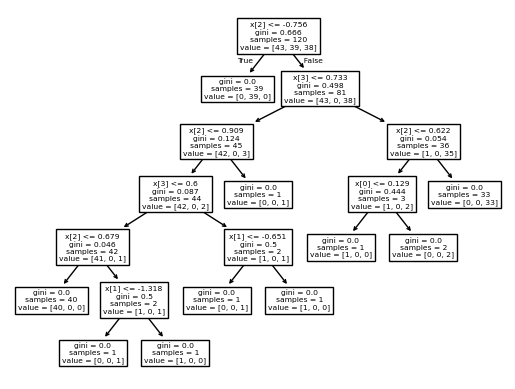

In [23]:
from sklearn import tree
tree.plot_tree(clf)